# Training — Zoobot ConvNeXt (Bloque A · Domain Shift Mínimo)

Notebook reutilizable que ejecuta únicamente llamadas a funciones definidas en `src/`.
Encoder **ConvNeXt-nano** preentrenado sobre ~10 M galaxias de Galaxy Zoo (Zoobot 2.0).

> **Referencia:** Walmsley et al. 2023 — *Scaling Laws for Galaxy Images* — arXiv:2404.02973  
> **Pesos:** `hf_hub:mwalmsley/zoobot-encoder-convnext_nano` (HuggingFace Hub)

## 1) Imports y configuración básica

In [1]:
import timm
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim

# Asegurar que la raíz del repo está en sys.path (notebook ubicado en `baseline/`)
sys.path.append(str(Path("..").resolve()))

from src import (
    CONFIG,
    CATALOG_PATH,
    FITS_DIR,
    build_dataloaders,
    calculate_class_weights,
    compute_classification_metrics,
    create_model_dir,
    evaluate_and_save,
    generate_gradcam_visualization,
    load_catalog,
    save_learning_curves,
    save_training_checkpoint,
    save_training_metadata,
    set_global_seed,
    split_catalog,
    train_loop,
    get_device,
)

# Builder específico para este experimento
from src.galaxy_model_builders import build_zoobot_convnext

print("Imports OK")


/home/azureuser/.cache/pypoetry/virtualenvs/ringgalaxiesanalysis-BYpApdNW-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 2) Semilla y dispositivo

In [2]:
set_global_seed(CONFIG["seed"])
device = get_device()
print(f"Using device: {device}")


Using device: cuda


## 3) Carga del catálogo y división estratificada

In [3]:
from pathlib import Path

catalog_path = Path(CATALOG_PATH)
report_path = Path("..") / "data" / "processed" / "dataset_validation_report.csv"

df = load_catalog(catalog_path, report_path=report_path)
train_df, val_df, test_df = split_catalog(df, seed=CONFIG["seed"])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 5868 | Val: 1258 | Test: 1258


## 4) Datasets y DataLoaders

> **Nota:** Zoobot ConvNeXt acepta cualquier tamaño de entrada.
> El `CONFIG["image_size"]` del proyecto se usa sin modificación.

In [4]:
train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = build_dataloaders(
    train_df,
    val_df,
    test_df,
    FITS_DIR,
    CONFIG,
)

print("Datasets and DataLoaders ready")


Datasets and DataLoaders ready


## 5) Construcción del modelo (Zoobot ConvNeXt-nano)

| Parámetro | Valor | Descripción |
|---|---|---|
| `variant` | `convnext_nano` | Encoder 256-d, 4.5 M params totales |
| `freeze_backbone` | `True` | Solo entrena la cabeza clasificadora |
| `head_hidden` | 128 | Igual que ResNet-18 baseline |
| `head_dropout` | 0.3 | Igual que ResNet-18 baseline |

Para probar variantes más grandes cambia `variant` a `convnext_tiny`, `convnext_small`, etc.

In [5]:
# Variante y nombre del experimento
ZOOBOT_VARIANT = "convnext_nano"   # opciones: convnext_pico | nano | tiny | small | base | large
model_name = f"zoobot_{ZOOBOT_VARIANT}"

model, trainable_params, frozen_params = build_zoobot_convnext(
    num_classes=CONFIG["num_classes"],
    variant=ZOOBOT_VARIANT,
    freeze_backbone=CONFIG.get("freeze_backbone", True),
    head_hidden=128,
    head_dropout=0.3,
    device=device,
)

print(f"Modelo      : Zoobot ConvNeXt-{ZOOBOT_VARIANT}")
print(f"Preentren.  : ~10M galaxias Galaxy Zoo (DESI / DECaLS / Rings)")
print(f"Encoder dim : 256-d")
print(f"Trainable params: {trainable_params:,} | Frozen params: {frozen_params:,}")


Modelo      : Zoobot ConvNeXt-convnext_nano
Preentren.  : ~10M galaxias Galaxy Zoo (DESI / DECaLS / Rings)
Encoder dim : 256-d
Trainable params: 82,306 | Frozen params: 14,952,560


## 6) Pérdida y optimizador

Idéntico al baseline. El `filter(lambda p: p.requires_grad, ...)` garantiza que el optimizer **solo actualice la cabeza** mientras el backbone Zoobot permanece congelado.

In [6]:
class_weights = calculate_class_weights(train_df, CONFIG["num_classes"], device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)

print("Criterion and optimizer ready")


Criterion and optimizer ready


## 7) Entrenamiento y guardado de artefactos

In [7]:
model_dir = create_model_dir(model_name)
checkpoint_path = model_dir / "checkpoint.pth"
history_path = model_dir / "history.json"

if checkpoint_path.exists() and history_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    history = checkpoint.get("history", {})
    print(f"Loaded existing checkpoint from {checkpoint_path}")
else:
    model, history = train_loop(
        model, train_loader, val_loader, criterion, optimizer, device,
        epochs=CONFIG["epochs"]
    )
    save_training_checkpoint(
        model,
        optimizer,
        history,
        CONFIG,
        class_weights,
        trainable_params,
        frozen_params,
        model_dir,
    )

training_meta = {
    "model_name": model_name,
    "architecture": "Zoobot ConvNeXt",
    "variant": ZOOBOT_VARIANT,
    "pretrained_on": "~10M galaxies Galaxy Zoo (DESI / DECaLS / Rings)",
    "domain_shift": "minimal",
    "encoder_dim": 256,
    "epochs": CONFIG["epochs"],
    "config": CONFIG,
    "trainable_params": trainable_params,
    "frozen_params": frozen_params,
    "dataset_split": {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
    "catalog_path": str(catalog_path),
    "fits_dir": str(FITS_DIR),
    "checkpoint_file": checkpoint_path.name,
    "history_file": history_path.name,
    "reference": "Walmsley et al. 2023, arXiv:2404.02973",
    "weights_hub": f"hf_hub:mwalmsley/zoobot-encoder-{ZOOBOT_VARIANT}",
}

save_training_metadata(model_dir, history, training_meta)
print(f"Model artifacts saved under: {model_dir}")


Epoch [1/10]


Train Loss: 0.5462 | Train Acc: 0.7626 | Train F1: 0.5452
Val Loss:   0.4847 | Val Acc:   0.8013 | Val F1:    0.5994
Epoch [2/10]


Train Loss: 0.4715 | Train Acc: 0.7953 | Train F1: 0.6006
Val Loss:   0.4630 | Val Acc:   0.7997 | Val F1:    0.5882
Epoch [3/10]


Train Loss: 0.4469 | Train Acc: 0.7994 | Train F1: 0.6109
Val Loss:   0.4473 | Val Acc:   0.8196 | Val F1:    0.6106
Epoch [4/10]


Train Loss: 0.4420 | Train Acc: 0.8045 | Train F1: 0.6208
Val Loss:   0.4345 | Val Acc:   0.8172 | Val F1:    0.6230
Epoch [5/10]


...

Train Loss: 0.4227 | Train Acc: 0.8137 | Train F1: 0.6372
Val Loss:   0.4217 | Val Acc:   0.8227 | Val F1:    0.6421
Epoch [7/10]


Train Loss: 0.4142 | Train Acc: 0.8177 | Train F1: 0.6452
Val Loss:   0.4220 | Val Acc:   0.7862 | Val F1:    0.6096
Epoch [8/10]


Train Loss: 0.4096 | Train Acc: 0.8165 | Train F1: 0.6428
Val Loss:   0.4149 | Val Acc:   0.7862 | Val F1:    0.6152
Epoch [9/10]


Train Loss: 0.4082 | Train Acc: 0.8216 | Train F1: 0.6520
Val Loss:   0.4096 | Val Acc:   0.8347 | Val F1:    0.6601
Epoch [10/10]


Train Loss: 0.3962 | Train Acc: 0.8274 | Train F1: 0.6572
Val Loss:   0.4218 | Val Acc:   0.8450 | Val F1:    0.6486
Model artifacts saved under: data/models/zoobot_convnext_nano


## 8) Evaluación final en Test Set

In [8]:
eval_dir = model_dir / "evaluation"
sample_names = test_df["name"].tolist()
metrics = evaluate_and_save(
    model,
    test_loader,
    device,
    compute_classification_metrics,
    eval_dir,
    sample_names=sample_names,
)

print("Test metrics:")
for key, value in metrics.items():
    print(f"{key}: {value}")


Test metrics:
accuracy: 0.8473767885532592
precision: 0.6219081272084805
recall: 0.6743295019157088
f1_score: 0.6470588235294118
roc_auc: 0.8876399312881174


## 9) Curvas de aprendizaje

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


Learning curves saved: data/models/zoobot_convnext_nano/learning_curves.png


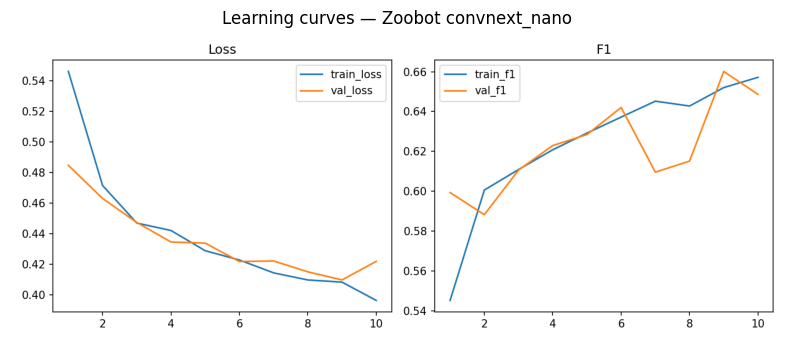

In [10]:
learning_curves_path = save_learning_curves(history, model_dir)
print(f"Learning curves saved: {learning_curves_path}")

img = mpimg.imread(learning_curves_path)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Learning curves — Zoobot {ZOOBOT_VARIANT}")
plt.show()


## 10) Grad-CAM de ejemplo

> **Nota Zoobot:** El encoder ConvNeXt es compatible con Grad-CAM sobre sus capas convolucionales.
> Si `generate_gradcam_visualization` usa `model.layer4` (ResNet), adapta el `target_layer`
> a `model.encoder.stages[-1]` para ConvNeXt.

In [11]:
gradcam_dir = model_dir / "gradcam"
gradcam_dir.mkdir(parents=True, exist_ok=True)
gradcam_path = gradcam_dir / "gradcam_positive_label1.png"

saved_path = generate_gradcam_visualization(
    model, test_dataset, device, target_label=1, save_path=gradcam_path
)
print(f"Grad-CAM saved: {saved_path}")

img = mpimg.imread(saved_path)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Grad-CAM for label 1 — Zoobot ConvNeXt")
plt.show()


RuntimeError: No se encontró una capa compatible para GradCAM en el modelo.

## 11) Notas

- Este notebook no define funciones nuevas: usa utilidades reutilizables de `src/` más `galaxy_model_builders.py`.
- Para cambiar de variante ConvNeXt edita únicamente `ZOOBOT_VARIANT` en la celda 5.
- Para fine-tuning completo del backbone cambia `freeze_backbone=False` y reduce el `learning_rate` a `1e-5` o `5e-6`.
- Comparación directa con baseline: los artefactos se guardan en `model_dir` con el mismo esquema de directorios que `resnet18_baseline`.


12) Mostrar predicciones

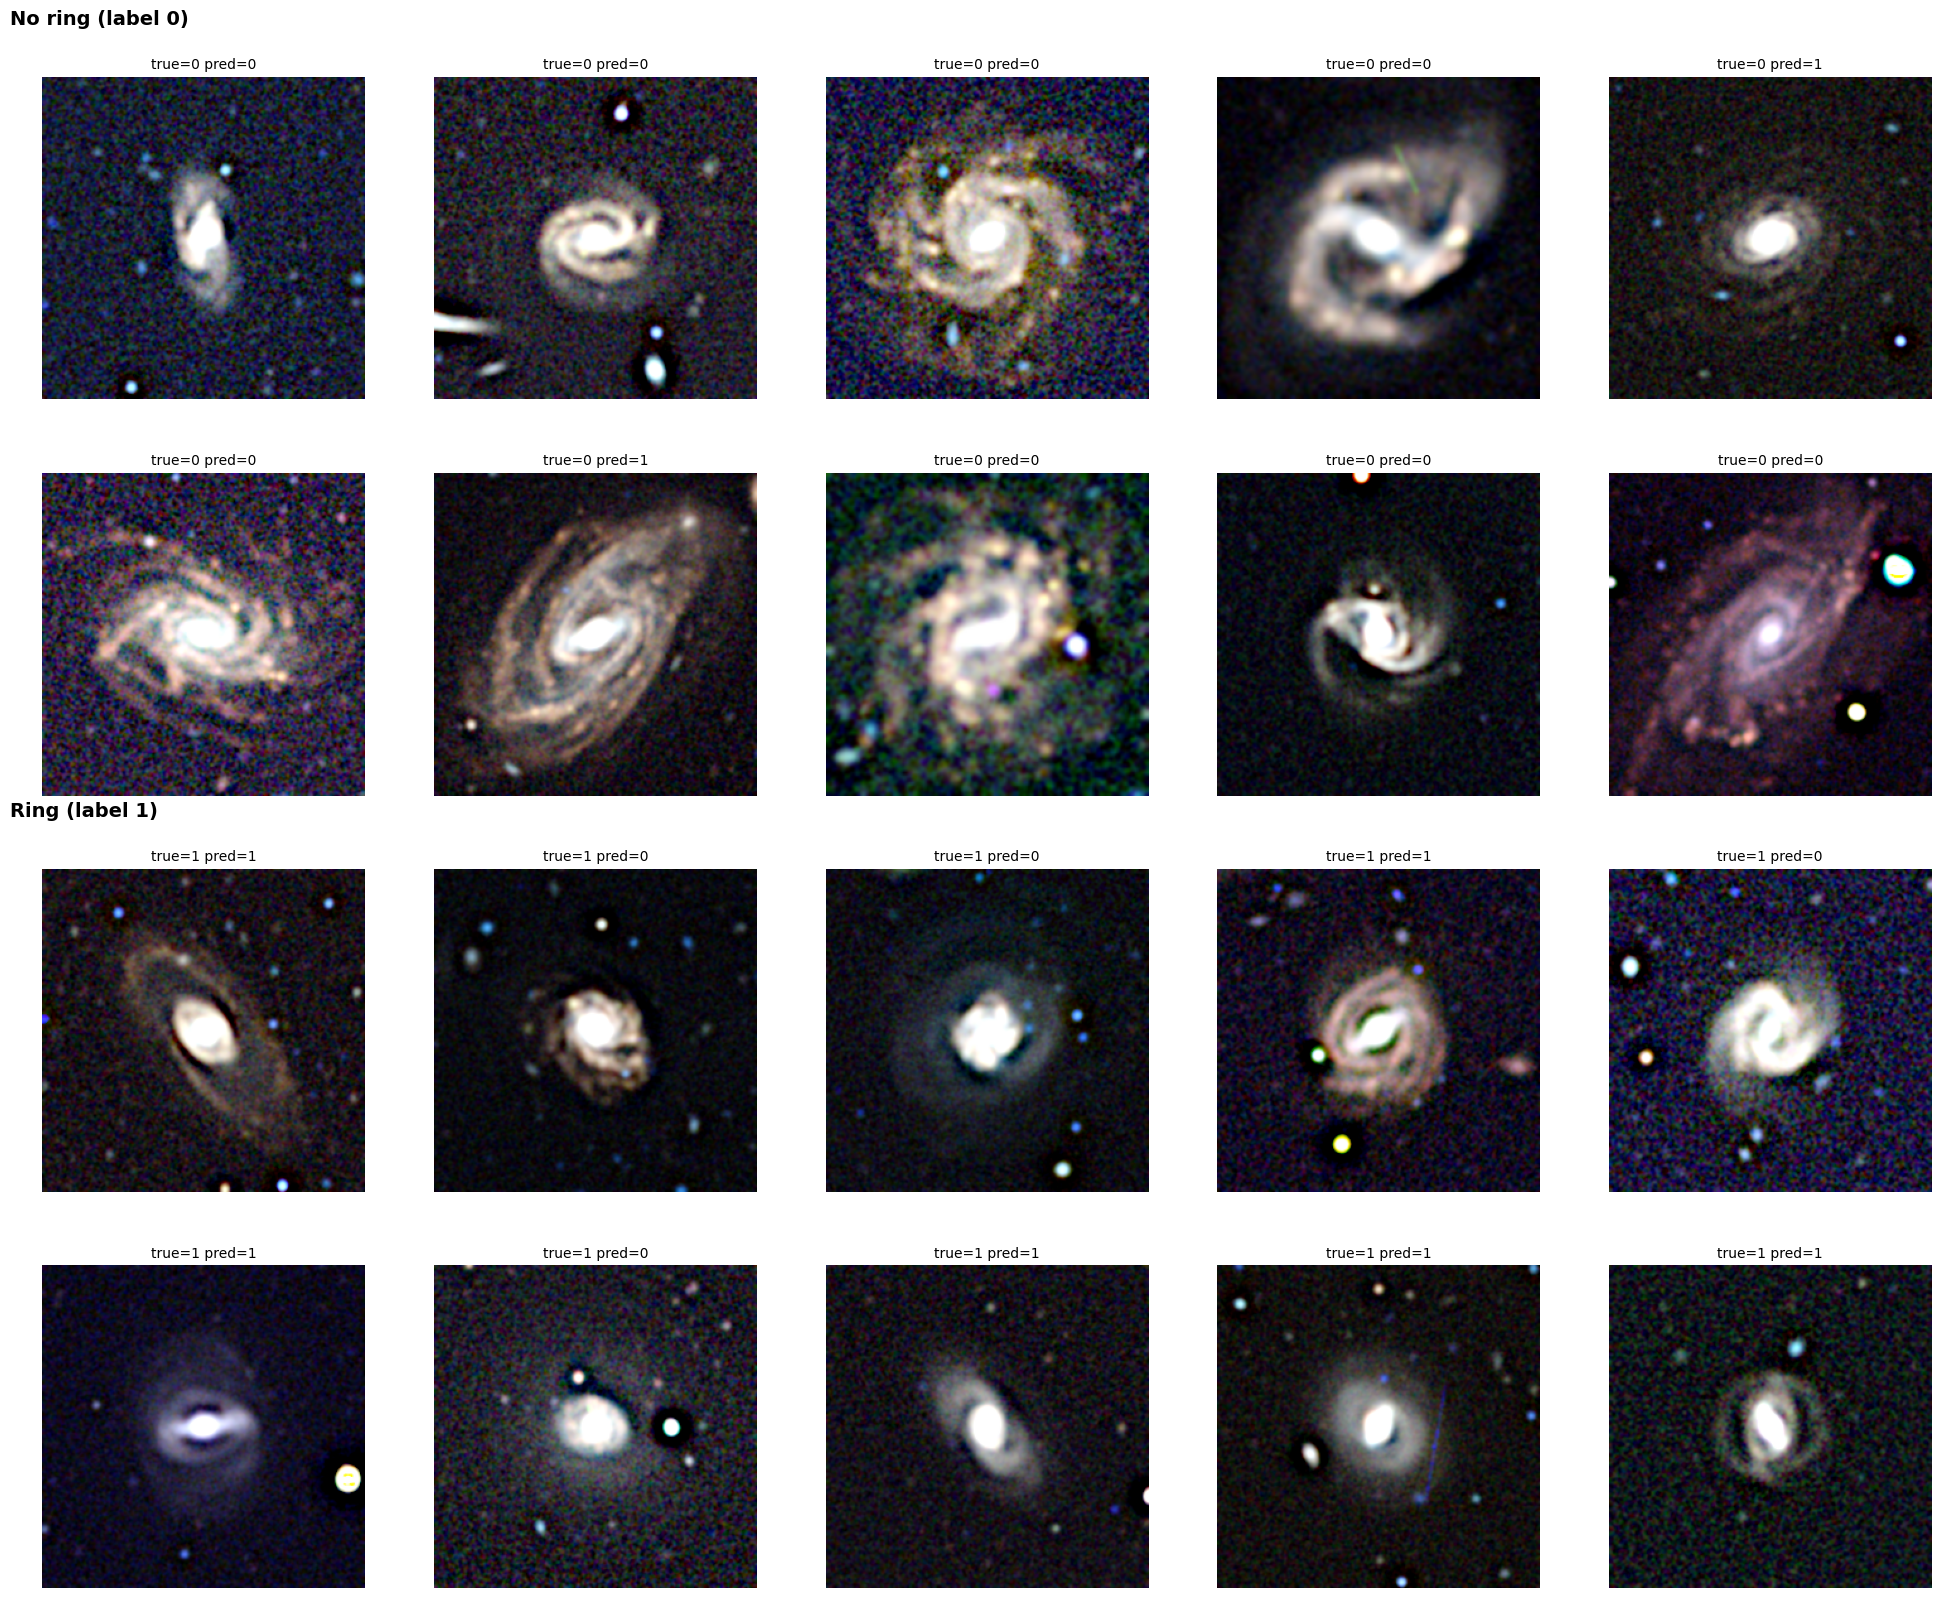

In [12]:
model.eval()

non_ring_indices = []
ring_indices = []

for idx in range(len(test_dataset)):
    sample = test_dataset[idx]
    if not isinstance(sample, (tuple, list)) or len(sample) < 2:
        continue

    label = sample[1]
    if isinstance(label, torch.Tensor):
        label = label.item()
    label = int(label)

    if label == 0 and len(non_ring_indices) < 10:
        non_ring_indices.append(idx)
    elif label == 1 and len(ring_indices) < 10:
        ring_indices.append(idx)

    if len(non_ring_indices) == 10 and len(ring_indices) == 10:
        break

selected_indices = non_ring_indices + ring_indices
images = []
true_labels = []
pred_labels = []
sample_names = []

with torch.no_grad():
    for idx in selected_indices:
        sample = test_dataset[idx]
        image = sample[0]
        label = sample[1]
        name = sample[2] if len(sample) > 2 else None

        image_tensor = image if isinstance(image, torch.Tensor) else torch.as_tensor(image)
        input_tensor = image_tensor.unsqueeze(0).to(device)

        logits = model(input_tensor)
        pred = int(logits.argmax(dim=1).item())

        images.append(image_tensor.cpu())
        true_labels.append(int(label.item()) if isinstance(label, torch.Tensor) else int(label))
        pred_labels.append(pred)
        sample_names.append(name)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for ax, img_tensor, true_label, pred_label, name in zip(
    axes, images, true_labels, pred_labels, sample_names
):
    img_np = img_tensor.numpy()

    if img_np.ndim == 3 and img_np.shape[0] in (1, 3, 4):
        img_np = img_np.transpose(1, 2, 0)

    if img_np.ndim == 3 and img_np.shape[2] == 4:
        img_np = img_np[..., :3]

    img_np = img_np.astype("float32")
    img_np = img_np - img_np.min()
    max_val = img_np.max()
    if max_val > 0:
        img_np = img_np / max_val

    cmap = "gray" if img_np.ndim == 2 or (img_np.ndim == 3 and img_np.shape[2] == 1) else None
    ax.imshow(img_np.squeeze(), cmap=cmap)
    ax.axis("off")

    title = f"true={true_label} pred={pred_label}"
    if name is not None:
        title += f"\n{name}"
    ax.set_title(title, fontsize=10)

axes[0].text(
    -0.1,
    1.15,
    "No ring (label 0)",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="bottom",
)
axes[10].text(
    -0.1,
    1.15,
    "Ring (label 1)",
    transform=axes[10].transAxes,
    fontsize=14,
    fontweight="bold",
    va="bottom",
)

plt.tight_layout()
plt.show()